In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
## Import Libraries
# Object manipulation
import statistics
import numpy as np
import pandas as pd
import xgboost as xgb
from collections import defaultdict

# Plot
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import seaborn as sns

# Scikit-Learn libraries
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn import tree
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.tree import plot_tree

# Analysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Optimisation
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


In [3]:
orders = pd.read_csv("/content/drive/My Drive/Y3S1/AI SOLUTION DEVELOPMENT PROJECT (EGT309)/final_merged_olist_with_geolocation.csv")
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.576983,-46.587161,-23.680729,-46.444238
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.576983,-46.587161,-23.680729,-46.444238
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.576983,-46.587161,-23.680729,-46.444238
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,belo horizonte,SP,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-12.177924,-44.660711,-19.807681,-43.980427
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,guariba,SP,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-16.745150,-48.514783,-21.363502,-48.229601


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114694 entries, 0 to 114693
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114694 non-null  object 
 1   customer_id                    114694 non-null  object 
 2   order_status                   114694 non-null  object 
 3   order_purchase_timestamp       114694 non-null  object 
 4   order_approved_at              114680 non-null  object 
 5   order_delivered_carrier_date   113511 non-null  object 
 6   order_delivered_customer_date  112323 non-null  object 
 7   order_estimated_delivery_date  114694 non-null  object 
 8   order_item_id                  114694 non-null  int64  
 9   product_id                     114694 non-null  object 
 10  seller_id                      114694 non-null  object 
 11  shipping_limit_date            114694 non-null  object 
 12  price                         

In [6]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_creation_date', 'review_answer_timestamp',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'customer_lat', 'customer_lng', 'seller_lat',
       'seller_lng'],
      dtype='object')

In [7]:
# Label creation: Is customer a repeat buyer?
customer_order_counts = orders.groupby("customer_unique_id")["order_id"].nunique()
repeat_buyer_map = (customer_order_counts > 1).astype(int)  # 1 if repeat buyer, else 0

# Add label to the main DataFrame
orders["repeat_buyer"] = orders["customer_unique_id"].map(repeat_buyer_map)


In [8]:
repeat_buyer_map.value_counts()

,count
order_id,
0,90966
1,2418


In [9]:
# Aggregate useful features
features_df = orders.groupby("customer_unique_id").agg({
    "order_id": "nunique",  # number of orders
    "payment_value": "sum",  # total money spent
    "freight_value": "sum",  # total shipping paid
    "review_score": "mean",  # average review score
    "product_category_name": "nunique",  # variety of product categories
    "order_item_id": "count",  # total items bought
    "customer_state": "first",  # customer state (will encode)
    "repeat_buyer": "first",  # label
}).rename(columns={
    "order_id": "num_orders",
    "payment_value": "total_spent",
    "freight_value": "shipping_fee",
    "review_score": "avg_review",
    "product_category_name": "unique_categories",
    "order_item_id": "total_items"
})


In [10]:
# Encode categorical columns
le = LabelEncoder()
features_df["customer_state"] = le.fit_transform(features_df["customer_state"])

# Features and labels
X = features_df.drop(columns=["repeat_buyer", "num_orders"])
y = features_df["repeat_buyer"]

### XG Boost

In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Initialize and train model
model = XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))
print('\n')
print('Accuracy: ', accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     27291
           1       0.86      0.65      0.74       725

    accuracy                           0.99     28016
   macro avg       0.92      0.82      0.87     28016
weighted avg       0.99      0.99      0.99     28016



Accuracy:  0.9881139348943461


In [12]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Placeholder for measure_error function (replace with your actual implementation)
def measure_error(y_true, y_pred, label):
    # Calculate error metrics here (e.g., accuracy, precision, recall, f1-score)
    # Return a pandas Series or DataFrame with the results
    return pd.Series({'accuracy':accuracy_score(y_true, y_pred),
                      'precision': precision_score(y_true, y_pred),
                      'recall': recall_score(y_true, y_pred),
                      'f1': f1_score(y_true, y_pred)},
                      name=label)
# Combine error metrics
train_test_full_error = pd.concat([
    measure_error(y_train, y_train_pred, 'train'),
    measure_error(y_test, y_test_pred, 'test')
], axis=1)

# Display results
train_test_full_error

,train,test
accuracy,0.991433,0.988114
precision,0.934766,0.856364
recall,0.719433,0.649655
f1,0.813084,0.738824


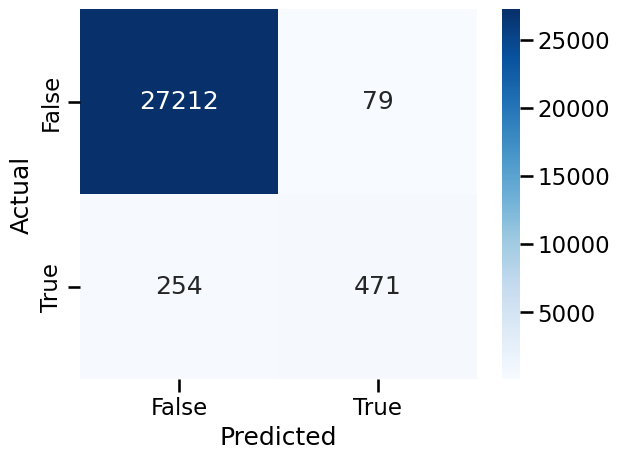

In [13]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.set_context('talk')
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
labels = ['False', 'True']
ax.set_xticklabels(labels);
ax.set_yticklabels(labels);
ax.set_ylabel('Actual');
ax.set_xlabel('Predicted');

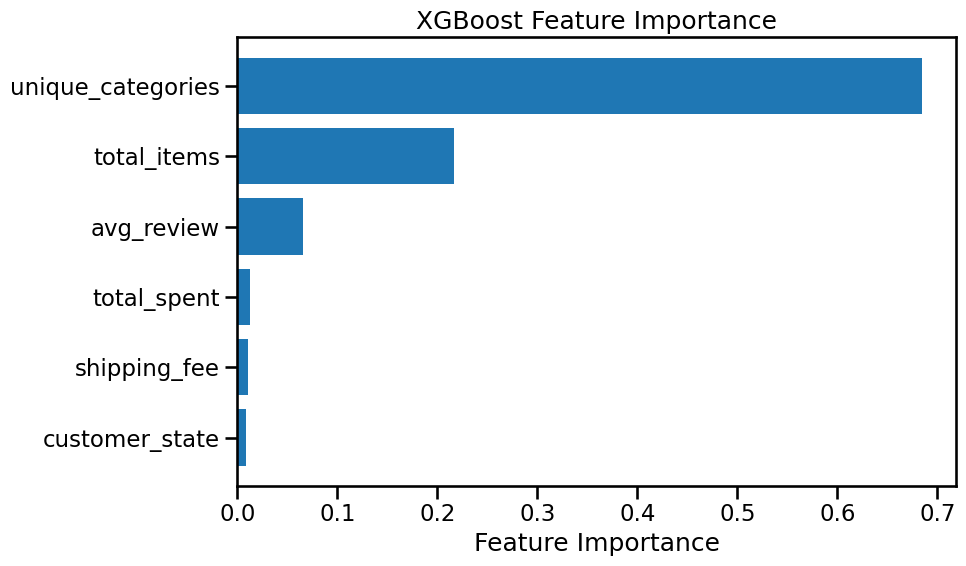

In [14]:
# Get feature importances from the trained XGBoost model
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Optimisation using GridSearch

In [15]:
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.002, 0.02, 0.2]
}

# Initialize XGBoost model
base_model = XGBClassifier(random_state=42)

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='f1',  # used 'f1_macro' or 'f1_weighted' due to class imbalance
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit to training data
grid_search.fit(X_train, y_train)

# Best estimator and parameters
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Predict with best model
y_pred = best_model.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Parameters: {'learning_rate': 0.2, 'n_estimators': 50}
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     27291
           1       0.87      0.65      0.75       725

    accuracy                           0.99     28016
   macro avg       0.93      0.83      0.87     28016
weighted avg       0.99      0.99      0.99     28016



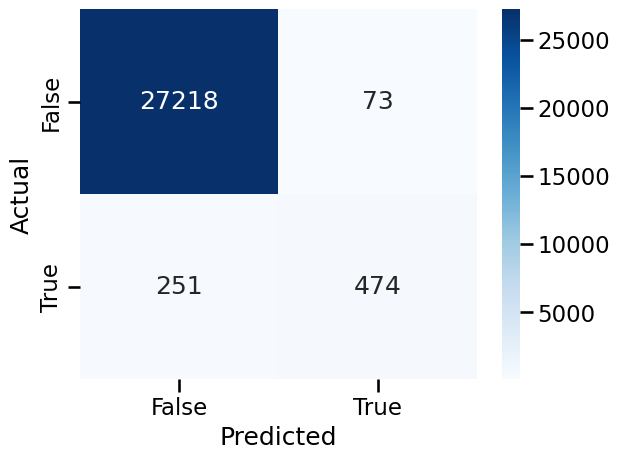

In [16]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.set_context('talk')
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
labels = ['False', 'True']
ax.set_xticklabels(labels);
ax.set_yticklabels(labels);
ax.set_ylabel('Actual');
ax.set_xlabel('Predicted');

In [17]:
# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Combine error metrics
train_test_full_error = pd.concat([
    measure_error(y_train, y_train_pred, 'train'),
    measure_error(y_test, y_test_pred, 'test')
], axis=1)

# Display results
train_test_full_error

,train,test
accuracy,0.989398,0.988435
precision,0.887597,0.866545
recall,0.676314,0.653793
f1,0.767684,0.745283


In [18]:
from sklearn.metrics import precision_recall_curve

# Get predicted probabilities for the positive class (Repeat Buyer = 1)
y_train_pred_prob = best_model.predict_proba(X_train)
y_train_scores = y_train_pred_prob[:, 1]  # Probabilities for class 1

# Compute precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_scores)


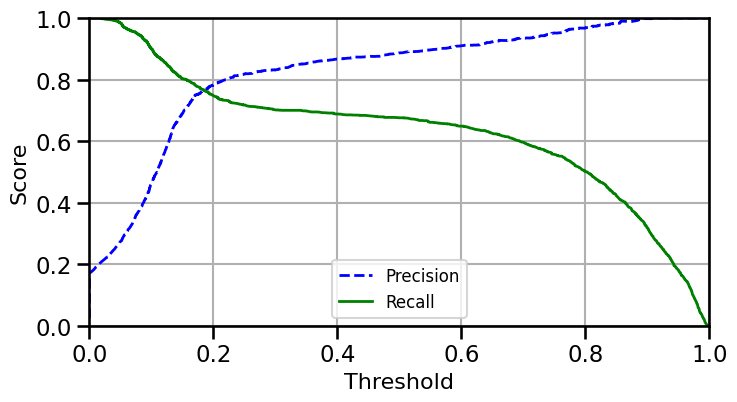

In [19]:
def plot_precision_recall_curve(precisions, recalls, thresholds):
    plt.figure(figsize=(8, 4))  # Make sure this is called before plotting
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.xlabel("Threshold", fontsize=16)
    plt.ylabel("Score", fontsize=16)
    plt.legend(loc="lower center", fontsize=12)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.grid(True)
plot_precision_recall_curve(precisions, recalls, thresholds)
plt.show()


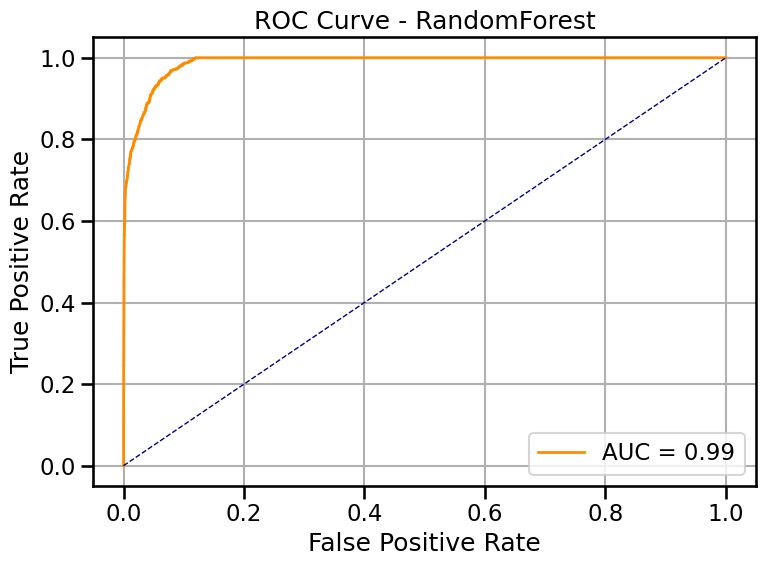

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for class 1 (positive class)
y_probs = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RandomForest")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
import joblib
# Assuming your model is named 'rf' or similar
joblib.dump(best_model, 'saved_model_XGBoost.pkl')

['saved_model_XGBoost.pkl']